# Residual_Unet_3D_5K vs SOTA (ETH3D real sample)

This notebook picks a random scene from `Dataset/ETH3d_2views/two_view_training`, loads the **GT disparity** from `two_view_training_gt 2`, converts it to **depth** using calibration parameters, and compares your **Residual_Unet_3D_5K** model to SOTA monocular models on that single sample.


In [45]:
%pip install torch torchvision transformers pillow matplotlib pandas



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [46]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
import tensorflow as tf
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

from Models_Arch.ResidualUnet_3Dense_5Kernels import Residual_Unet_3D_5K

OUTPUT_DIR = Path("visuals")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = Path("Dataset/ETH3d_2views/two_view_training")
GT_DIR = Path("Dataset/ETH3d_2views/two_view_training_gt 2")

USE_RANDOM_SCENE = False
RANDOM_SEED = 1
SCENE_NAME = "electro_2s"  # used only if USE_RANDOM_SCENE=False

# Residual model
MODEL_PATH = Path("Residual_Unet_3D_5K.keras")

# Resize to match training shape (W,H)
RESIZE_TO = (480, 256)

# Alignment option for fair comparison
ALIGN_TO_GT = True  # set False to compare absolute scales

MODEL_IDS = {
    "DPT-Large": "Intel/dpt-large",
    "Depth-Anything-V2-Small": "depth-anything/Depth-Anything-V2-Small-hf",
    "ZoeDepth-NK": "Intel/zoedepth-nyu-kitti",
}

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

for p in [DATASET_DIR, GT_DIR, MODEL_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing path: {p.resolve()}")


Using device: mps


In [47]:
def read_pfm(path: Path):
    with open(path, "rb") as f:
        header = f.readline().rstrip().decode("ascii")
        if header not in ("PF", "Pf"):
            raise ValueError(f"Not a PFM file: {path}")
        dims = f.readline().decode("ascii").strip()
        while dims.startswith("#"):
            dims = f.readline().decode("ascii").strip()
        width, height = map(int, dims.split())
        scale = float(f.readline().decode("ascii").strip())
        endian = "<" if scale < 0 else ">"
        data = np.fromfile(f, endian + "f")
        channels = 3 if header == "PF" else 1
        expected = width * height * channels
        if data.size != expected:
            raise ValueError(f"PFM size mismatch: expected {expected}, got {data.size}")
        data = data.reshape((height, width, channels)) if channels == 3 else data.reshape((height, width))
        data = np.flipud(data)
        return data.astype(np.float32)


def parse_calib(path: Path):
    fx = fy = None
    baseline = None
    width = height = None
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("cam0="):
                # cam0=[fx 0 cx; 0 fy cy; 0 0 1]
                nums = line.split("=")[1].replace("[", "").replace("]", "").replace(";", " ")
                vals = [float(v) for v in nums.split()]
                fx = vals[0]
                fy = vals[4]
            elif line.startswith("baseline="):
                baseline = float(line.split("=")[1])
            elif line.startswith("width="):
                width = int(float(line.split("=")[1]))
            elif line.startswith("height="):
                height = int(float(line.split("=")[1]))
    if fx is None or baseline is None or width is None or height is None:
        raise ValueError(f"Missing calib fields in {path}")
    return fx, fy if fy is not None else fx, baseline, width, height


def robust_minmax(arr: np.ndarray, valid_mask: np.ndarray):
    if not np.any(valid_mask):
        return 0.0, 1.0
    vals = arr[valid_mask]
    vmin = np.percentile(vals, 2)
    vmax = np.percentile(vals, 98)
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return float(vmin), float(vmax)


In [48]:
scenes = sorted([p.name for p in DATASET_DIR.iterdir() if p.is_dir()])
if not scenes:
    raise FileNotFoundError("No scenes found in ETH3D training set")

if USE_RANDOM_SCENE:
    rng = np.random.default_rng(RANDOM_SEED)
    SCENE_NAME = rng.choice(scenes)

scene_dir = DATASET_DIR / SCENE_NAME
scene_gt_dir = GT_DIR / SCENE_NAME
if not scene_gt_dir.exists():
    raise FileNotFoundError(f"Missing GT folder: {scene_gt_dir}")

print(f"Selected scene: {SCENE_NAME}")


Selected scene: electro_2s


In [49]:
left_path = scene_dir / "im0.png"
right_path = scene_dir / "im1.png"
disp_path = scene_gt_dir / "disp0GT.pfm"
mask_path = scene_gt_dir / "mask0nocc.png"
calib_path = scene_dir / "calib.txt"

for p in [left_path, right_path, disp_path, mask_path, calib_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p.resolve()}")

left_img = Image.open(left_path).convert("RGB")
right_img = Image.open(right_path).convert("RGB")
disp = read_pfm(disp_path)
mask = Image.open(mask_path)

fx, fy, baseline, width, height = parse_calib(calib_path)
print(f"Calib: fx={fx}, baseline={baseline}, size=({width},{height})")


Calib: fx=713.679, baseline=60.1004, size=(717,435)


In [50]:
scale_x = RESIZE_TO[0] / width
scale_y = RESIZE_TO[1] / height

left_img = left_img.resize(RESIZE_TO, Image.BILINEAR)
right_img = right_img.resize(RESIZE_TO, Image.BILINEAR)

disp_resized = Image.fromarray(disp.astype(np.float32)).resize(RESIZE_TO, Image.BILINEAR)
disp_resized = np.array(disp_resized).astype(np.float32) * scale_x

mask_resized = mask.resize(RESIZE_TO, Image.NEAREST)
mask_resized = np.array(mask_resized) > 0

fx_resized = fx * scale_x
baseline_resized = baseline  # baseline is in world units, not pixels

valid = (disp_resized > 0) & mask_resized
depth_gt = np.zeros_like(disp_resized, dtype=np.float32)
depth_gt[valid] = (fx_resized * baseline_resized) / disp_resized[valid]

left_rgb = np.array(left_img)
right_rgb = np.array(right_img)

# Residual model trained with cv2.imread (BGR). Convert RGB -> BGR.
left_bgr = left_rgb[..., ::-1]
right_bgr = right_rgb[..., ::-1]

print(f"Resized left: {left_rgb.shape}, depth: {depth_gt.shape}")


Resized left: (256, 480, 3), depth: (256, 480)


In [51]:
models = {}
for name, model_id in MODEL_IDS.items():
    print(f"Loading {name} ({model_id})...")
    processor = AutoImageProcessor.from_pretrained(model_id)
    model = AutoModelForDepthEstimation.from_pretrained(model_id).to(device)
    model.eval()
    models[name] = (processor, model)

print("Loading Residual_Unet_3D_5K...")
residual_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"Residual_Unet_3D_5K": Residual_Unet_3D_5K},
    compile=False,
)
residual_model.trainable = False
print(f"Loaded {len(models)} SOTA models + Residual_Unet_3D_5K")


Loading DPT-Large (Intel/dpt-large)...


Loading weights: 100%|██████████| 458/458 [00:00<00:00, 8035.10it/s]
[transformers] DPTForDepthEstimation LOAD REPORT from: Intel/dpt-large
Key                                                            | Status  | 
---------------------------------------------------------------+---------+-
neck.fusion_stage.layers.0.residual_layer1.convolution1.weight | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution1.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.bias   | MISSING | 
neck.fusion_stage.layers.0.residual_layer1.convolution2.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading Depth-Anything-V2-Small (depth-anything/Depth-Anything-V2-Small-hf)...


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 9900.20it/s]


Loading ZoeDepth-NK (Intel/zoedepth-nyu-kitti)...


Loading weights: 100%|██████████| 647/647 [00:00<00:00, 7746.50it/s]


Loading Residual_Unet_3D_5K...
Loaded 3 SOTA models + Residual_Unet_3D_5K


In [52]:
def predict_depth_sota(model_bundle, pil_image: Image.Image) -> np.ndarray:
    processor, model = model_bundle
    inputs = processor(images=pil_image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        pred = model(**inputs).predicted_depth
        pred = F.interpolate(
            pred.unsqueeze(1),
            size=pil_image.size[::-1],
            mode="bicubic",
            align_corners=False,
        ).squeeze().cpu().numpy().astype(np.float32)
    return pred


def predict_residual(model, left: np.ndarray, right: np.ndarray) -> np.ndarray:
    left_in = np.asarray(left, dtype=np.float32)[None, ...]
    right_in = np.asarray(right, dtype=np.float32)[None, ...]
    pred = model.predict([left_in, right_in], verbose=0)
    return np.squeeze(pred).astype(np.float32)


def scale_align_prediction(pred: np.ndarray, gt: np.ndarray, valid_mask: np.ndarray) -> np.ndarray:
    pred_valid = pred[valid_mask]
    gt_valid = gt[valid_mask]
    pred_med = np.median(pred_valid)
    gt_med = np.median(gt_valid)
    if pred_med <= 0:
        return pred
    return pred * (gt_med / pred_med)


def depth_metrics(pred: np.ndarray, gt: np.ndarray, valid_mask: np.ndarray):
    p = pred[valid_mask]
    g = gt[valid_mask]
    abs_rel = float(np.mean(np.abs(p - g) / np.clip(g, 1e-6, None)))
    rmse = float(np.sqrt(np.mean((p - g) ** 2)))
    return {"AbsRel": abs_rel, "RMSE": rmse}


In [53]:
# Residual prediction
pred_residual = predict_residual(residual_model, left_bgr, right_bgr)
if ALIGN_TO_GT:
    pred_residual = scale_align_prediction(pred_residual, depth_gt, valid)
metrics_res = depth_metrics(pred_residual, depth_gt, valid)

rows = [{"model": "Residual_Unet_3D_5K", **metrics_res}]
preds_for_plot = {"Residual_Unet_3D_5K": pred_residual}

for model_name, bundle in models.items():
    pred = predict_depth_sota(bundle, left_img)
    if ALIGN_TO_GT:
        pred = scale_align_prediction(pred, depth_gt, valid)
    metrics = depth_metrics(pred, depth_gt, valid)
    rows.append({"model": model_name, **metrics})
    preds_for_plot[model_name] = pred


/Users/ahmed_ali/.pyenv/versions/3.11.6/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['first_image', 'second_image']. Received: the structure of inputs=('*', '*')
  warnings.warn(


In [54]:
df = pd.DataFrame(rows)
display(df)

csv_path = OUTPUT_DIR / f"residual_vs_sota_eth3d_real_sample_{SCENE_NAME}.csv"
df.to_csv(csv_path, index=False)
print(f"Saved metrics to: {csv_path.resolve()}")


,model,AbsRel,RMSE
0,Residual_Unet_3D_5K,530452192.0,2052.567627
1,DPT-Large,505146176.0,1867.095947
2,Depth-Anything-V2-Small,505009504.0,1866.699951
3,ZoeDepth-NK,576917376.0,2760.666748


Saved metrics to: /Users/ahmed_ali/Downloads/DeepView3D-main/visuals/residual_vs_sota_eth3d_real_sample_electro_2s.csv


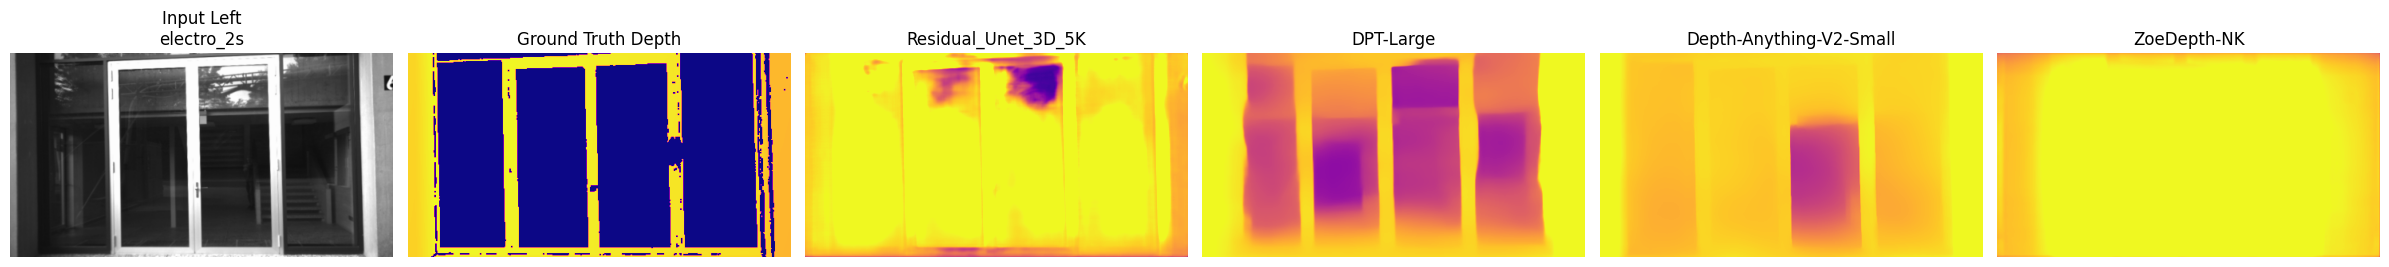

Saved comparison image to: /Users/ahmed_ali/Downloads/DeepView3D-main/visuals/residual_vs_sota_eth3d_real_sample_electro_2s.png


In [55]:
vmin, vmax = robust_minmax(depth_gt, valid)
num_cols = 2 + len(preds_for_plot)
fig, axes = plt.subplots(1, num_cols, figsize=(4 * num_cols, 4))

axes[0].imshow(left_img)
axes[0].set_title(f"Input Left\n{SCENE_NAME}")
axes[0].axis("off")

axes[1].imshow(depth_gt, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].set_title("Ground Truth Depth")
axes[1].axis("off")

for col_idx, (name, pred) in enumerate(preds_for_plot.items(), start=2):
    axes[col_idx].imshow(pred, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[col_idx].set_title(name)
    axes[col_idx].axis("off")

plt.tight_layout()
out_path = OUTPUT_DIR / f"residual_vs_sota_eth3d_real_sample_{SCENE_NAME}.png"
fig.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved comparison image to: {out_path.resolve()}")
